# Contador Automático de Células Musculares
## Aprendizaje Profundo y Aprendizaje por Refuerzo — **Run**

**Autores:** Bautista Mercado Ricardo · Trejo Melena Jesús Adrián · Pérez Bravo Octavio  
**Institución:** Universidad Internacional de La Rioja  
**Seminario:** Innovación en Inteligencia Artificial  

## 1. Configuración del Entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-043ch2hi
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-043ch2hi
  Resolved https://www.github.com/mouseland/cellpose.git to commit 849ca11f17882219f9968217eab3f6b19e3ce8aa
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 60.6 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.1.0-py3-none-any.whl size=213150 sha256=2eef829d401cbe994b2131e89224cac4dba25c39849a9be34296fceb58d18d12
  Stored in directory: /tmp/pip-ephem-wheel-cache-khhixw0l/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from cellpose import models, utils
from skimage import io as skio
import os
import re
import gdown

Descargar modelo e imagen de prueba

In [ ]:
# --- FUNCIÓN DE DESCARGA ---
def descargar_de_drive(url, nombre_salida):
    """Extrae el ID de la URL y descarga el archivo usando gdown."""
    try:
        # Extraer el ID (cadena de caracteres entre /d/ y /view o similar)
        match = re.search(r'[-\w]{25,}', url)
        if not match:
            print(f"❌ No se reconoció un ID válido en la URL: {url}")
            return None

        file_id = match.group(0)
        # Descarga silenciosa y forzada
        ruta_final = gdown.download(id=file_id, output=nombre_salida, quiet=False, fuzzy=True)
        return ruta_final
    except Exception as e:
        print(f"❌ Error al descargar: {e}")
        return None

# --- 1. CONFIGURACIÓN DE LAS URLS ---
# Enlaces compartidos de Google Drive
url_modelo = 'https://drive.google.com/file/d/1rJzPz5gvGkDMWkkba7f81Y5hVr6yeqkd/view?usp=drive_link'
url_imagen = 'https://drive.google.com/file/d/12_MtOiRI_kUNVoITUipCB_Q0alPe--8g/view?usp=drive_link'

# Nombres temporales para los archivos en Colab
path_modelo_local = "model_base_3A"
path_imagen_local = "imagen_para_segmentar.tif" #la imagen

# --- 2. EJECUCIÓN DE DESCARGAS ---
print("revisando archivos...")
modelo_listo = descargar_de_drive(url_modelo, path_modelo_local)
imagen_lista = descargar_de_drive(url_imagen, path_imagen_local)

revisando archivos...


Downloading...
From (original): https://drive.google.com/uc?id=1rJzPz5gvGkDMWkkba7f81Y5hVr6yeqkd
From (redirected): https://drive.google.com/uc?id=1rJzPz5gvGkDMWkkba7f81Y5hVr6yeqkd&confirm=t&uuid=648a577f-5d7c-4639-ac50-5658e7a5dc3b
To: /content/model_base_3A
100%|██████████| 1.22G/1.22G [00:06<00:00, 190MB/s]
Downloading...
From: https://drive.google.com/uc?id=12_MtOiRI_kUNVoITUipCB_Q0alPe--8g
To: /content/imagen_para_segmentar.tif
100%|██████████| 525k/525k [00:00<00:00, 112MB/s]


# Prueba de funcionamiento

📂 Archivo de modelo localizado: /content/model_base_3A


🤖 Se está usando: model_base_3A


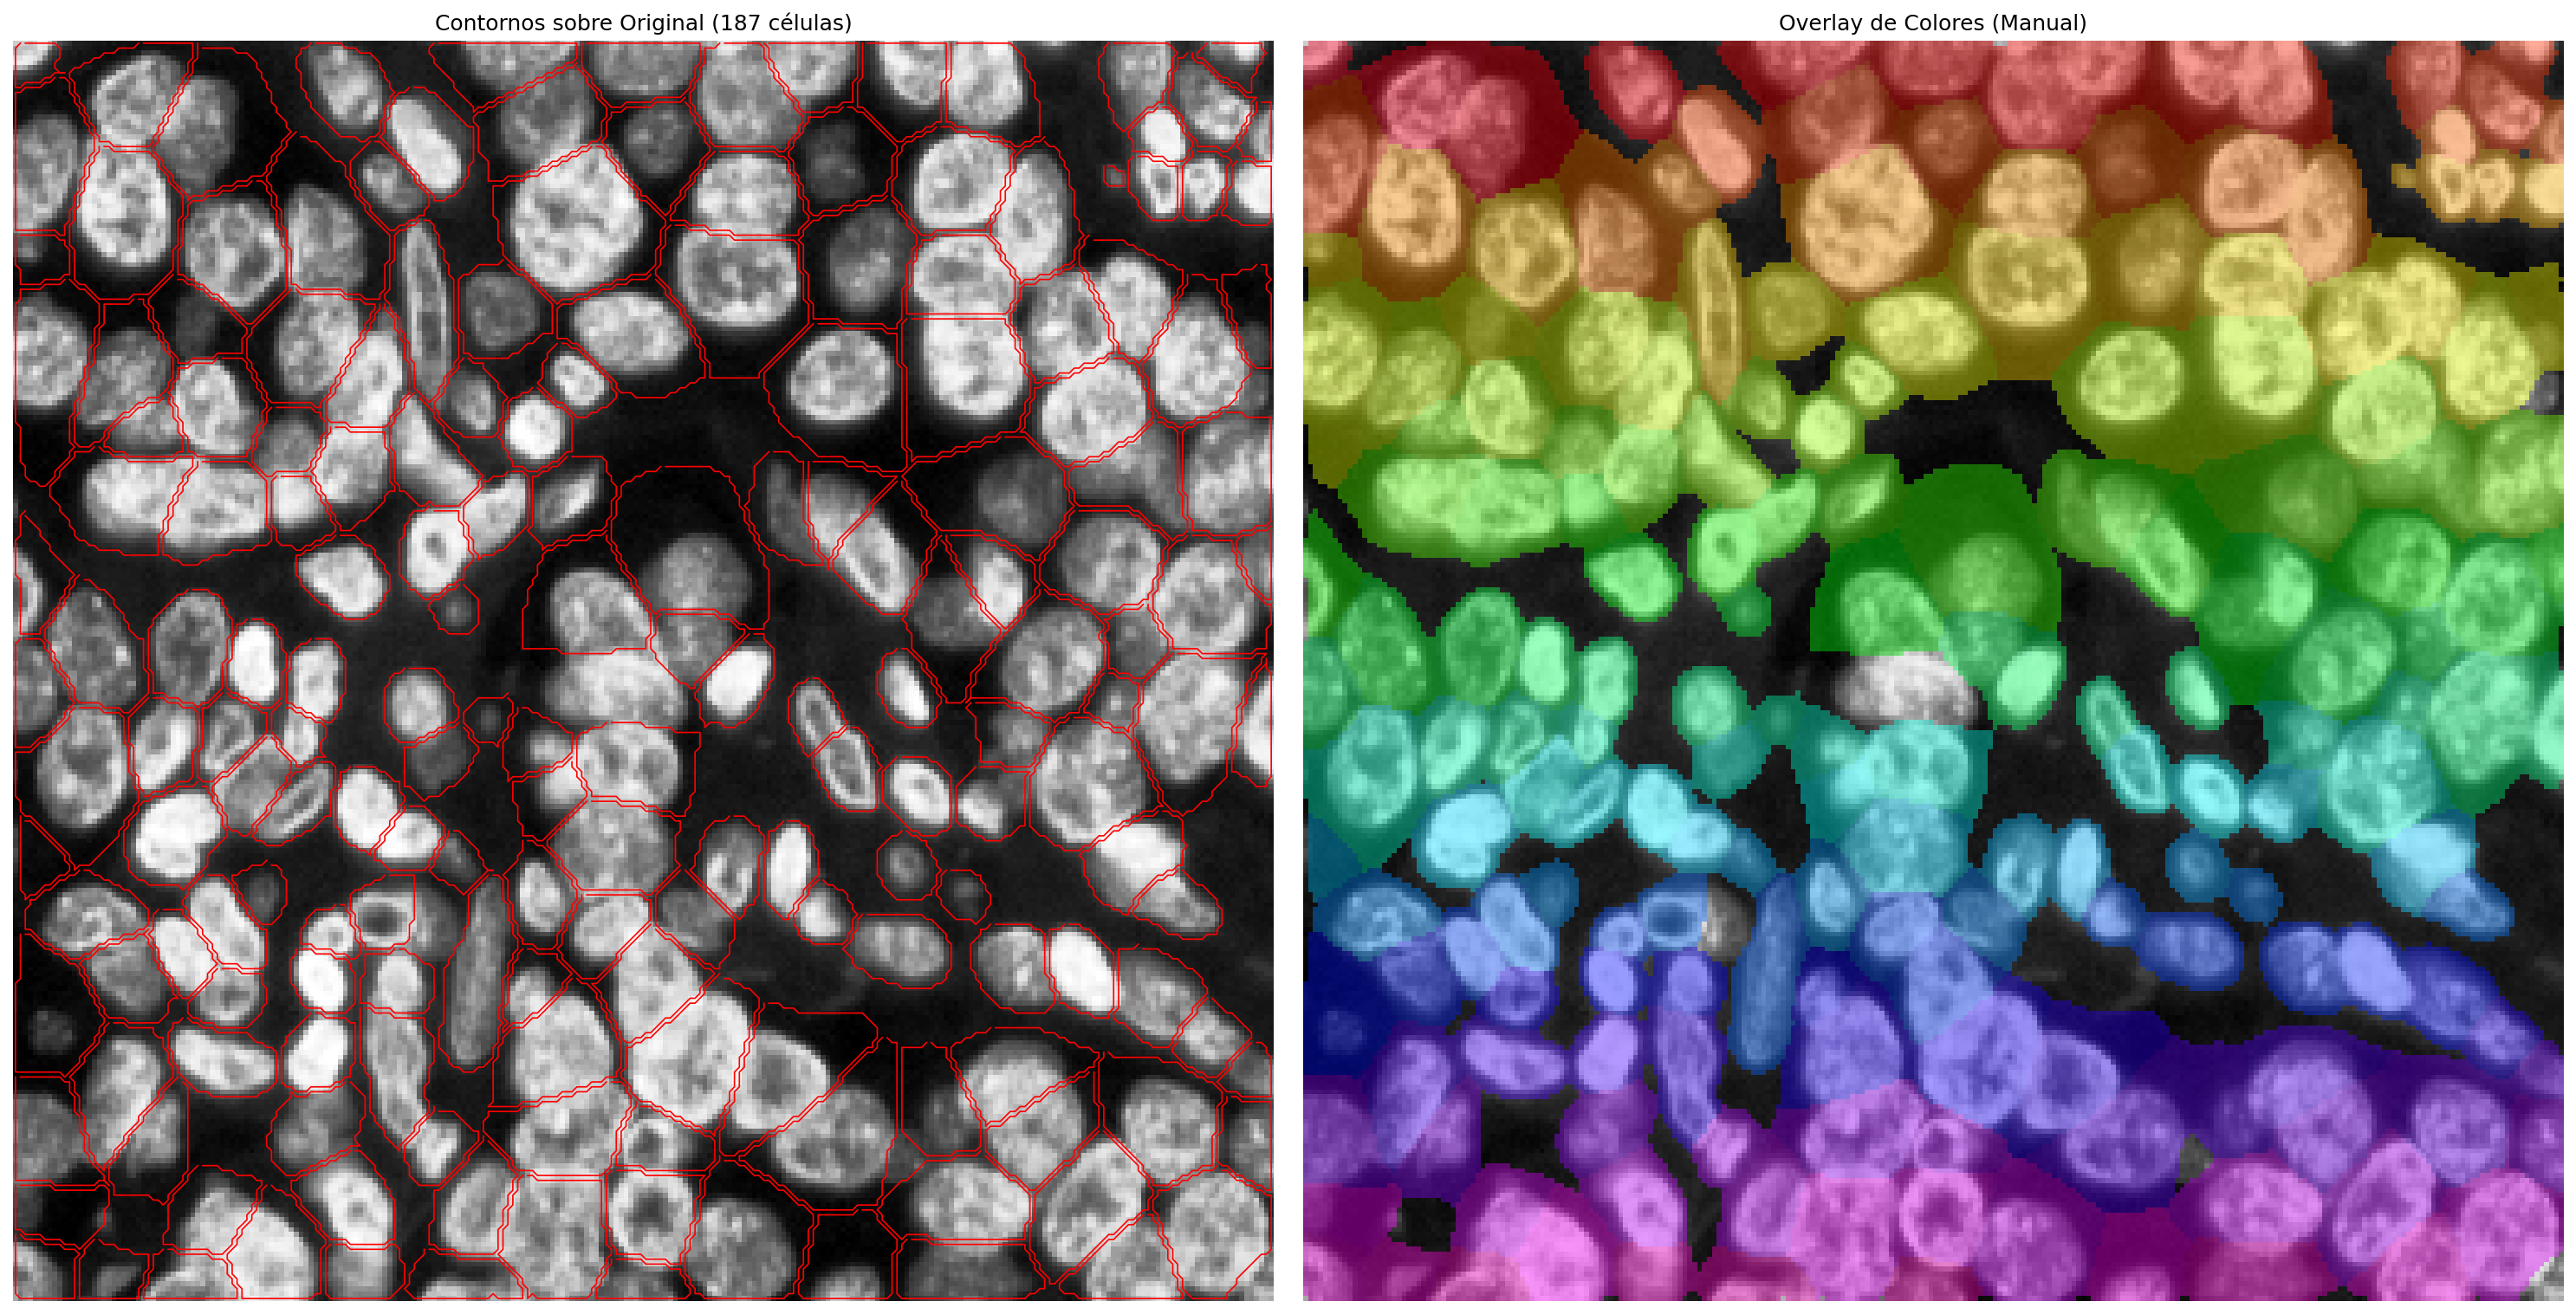

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from cellpose import models, utils
from skimage import io as skio
from google.colab import drive
import os
import glob

# 1. MONTAR DRIVE
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. RUTAS
ruta_imagen = '/content/imagen_para_segmentar.tif'
folder_modelos = '/content/'
nombre_base_modelo = 'model_base_3A'

# BUSCAR ARCHIVOS REALES (Cellpose les pone fecha al final)
archivos_modelo = glob.glob(os.path.join(folder_modelos, f"{nombre_base_modelo}*"))

if not archivos_modelo:
    # SI NO HAY ARCHIVOS, LANZAMOS UN ERROR Y DETENEMOS TODO
    raise FileNotFoundError(f"❌ No se encontró ningún modelo que empiece con '{nombre_base_modelo}' en {folder_modelos}. Revisa si el nombre es correcto.")

# Tomamos el más reciente (el último creado)
path_to_model = max(archivos_modelo, key=os.path.getctime)
print(f"📂 Archivo de modelo localizado: {path_to_model}")

# 3. CARGAR E INFERIR
if os.path.exists(ruta_imagen):
    img = skio.imread(ruta_imagen)

    # CARGAR EL MODELO (IMPORTANTE: Primero cargamos, luego consultamos)
    model = models.CellposeModel(gpu=True, pretrained_model=path_to_model)

    # AHORA SÍ, CONFIRMAMOS QUÉ CARGÓ EL MODELO
    print(f"🤖 Se está usando: {os.path.basename(model.pretrained_model)}")

    # Predecir
    masks, flows, styles = model.eval(img, diameter=None, channels=[0,0])

    # --- 4. VISUALIZACIÓN ---
    plt.figure(figsize=(20, 10), dpi=150)

    # Preparar fondo
    if img.ndim == 3:
        img_bg = img[:,:,0] if img.shape[-1] < img.shape[0] else img[0,:,:]
    else:
        img_bg = img

    # Normalizar fondo para visualización (0 a 1)
    img_bg = (img_bg - img_bg.min()) / (img_bg.max() - img_bg.min() + 1e-8)

    # --- PANEL 1: CONTORNOS ---
    plt.subplot(1, 2, 1)
    plt.imshow(img_bg, cmap='gray')
    outlines = utils.outlines_list(masks)
    for o in outlines:
        plt.plot(o[:,0], o[:,1], color='red', linewidth=0.8)
    plt.title(f'Contornos sobre Original ({len(outlines)} células)')
    plt.axis('off')

    # --- PANEL 2: OVERLAY MANUAL ---
    plt.subplot(1, 2, 2)
    plt.imshow(img_bg, cmap='gray')
    overlay_rgba = np.zeros((*masks.shape, 4))
    num_masks = masks.max()
    if num_masks > 0:
        for i in range(1, num_masks + 1):
            color = plt.cm.gist_rainbow(i / num_masks)
            overlay_rgba[masks == i] = color
            overlay_rgba[masks == i, 3] = 0.4
    plt.imshow(overlay_rgba)
    plt.title('Overlay de Colores (Manual)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontró la imagen en {ruta_imagen}")